In [12]:
# ==========================================
# Import Required Libraries
# Smart ATM Cash Demand Forecasting Using LSTM
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Date and Time
from datetime import datetime

# Data Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

print("Libraries Imported Successfully")

Libraries Imported Successfully
Libraries Imported Successfully


In [14]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("/content/Smart_ATM_Cash_Demand_Dataset.csv")

df.head()

print("Dataset Shape :", df.shape)

df.info()



Dataset Shape : (15000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   transactionTime           15000 non-null  object
 1   atmId                     15000 non-null  object
 2   atmName                   15000 non-null  object
 3   atmCity                   15000 non-null  object
 4   atmAddress                15000 non-null  object
 5   day                       15000 non-null  object
 6   hour                      15000 non-null  int64 
 7   isWeekend                 15000 non-null  int64 
 8   totalBalance              15000 non-null  int64 
 9   numberIncomeTransaction   15000 non-null  int64 
 10  numberOutcomeTransaction  15000 non-null  int64 
 11  totalIncome               15000 non-null  int64 
 12  totalOutcome              15000 non-null  int64 
 13  totalNumberTransaction    15000 non-null  int64 

In [15]:
df.describe(include="all")

df.isnull().sum()

df.duplicated().sum()

print(df.columns.tolist())

['transactionTime', 'atmId', 'atmName', 'atmCity', 'atmAddress', 'day', 'hour', 'isWeekend', 'totalBalance', 'numberIncomeTransaction', 'numberOutcomeTransaction', 'totalIncome', 'totalOutcome', 'totalNumberTransaction']


Select One ATM



In [16]:
#Display Available ATM IDs
print(df["atmId"].unique())
#Count Number of ATMs
print("Total ATMs :", df["atmId"].nunique())
#Display Transactions per ATM
df["atmId"].value_counts()

['ATM001']
Total ATMs : 1


,count
atmId,
ATM001,15000


In [17]:
selected_atm = "ATM001"

atm_df = df[df["atmId"] == selected_atm].copy()

print("Selected ATM :", selected_atm)
print("Total Records :", len(atm_df))

Selected ATM : ATM001
Total Records : 15000


In [18]:
#Display First Five Records
atm_df.head()
#Check Missing Values
atm_df.isnull().sum()
#Remove Duplicate Records
atm_df = atm_df.drop_duplicates()

print("Dataset Shape :", atm_df.shape)

Dataset Shape : (15000, 14)


In [19]:
# ==========================================
# Feature Engineering
# Smart ATM Cash Demand Forecasting Using LSTM
# ==========================================

# Convert transactionTime to datetime format
atm_df["transactionTime"] = pd.to_datetime(atm_df["transactionTime"])

print("Transaction Time Data Type:")
print(atm_df["transactionTime"].dtype)

# --------------------------------------------------
# Sort the dataset in chronological order
# --------------------------------------------------

atm_df = atm_df.sort_values("transactionTime")
atm_df = atm_df.reset_index(drop=True)

print("\nDataset Sorted Successfully")

# --------------------------------------------------
# Extract Time-Based Features
# --------------------------------------------------

atm_df["Year"] = atm_df["transactionTime"].dt.year
atm_df["Month"] = atm_df["transactionTime"].dt.month
atm_df["Day"] = atm_df["transactionTime"].dt.day
atm_df["Hour"] = atm_df["transactionTime"].dt.hour
atm_df["DayOfWeek"] = atm_df["transactionTime"].dt.dayofweek
atm_df["Week"] = atm_df["transactionTime"].dt.isocalendar().week.astype(int)

print("\nTime-Based Features Created Successfully")

# --------------------------------------------------
# Display First Five Records
# --------------------------------------------------

print("\nFirst Five Records")
display(atm_df.head())

# --------------------------------------------------
# Display Dataset Information
# --------------------------------------------------

print("\nDataset Information")
atm_df.info()

# --------------------------------------------------
# Statistical Summary
# --------------------------------------------------

print("\nStatistical Summary")
display(atm_df.describe())

# --------------------------------------------------
# Display Date Range
# --------------------------------------------------

print("\nDate Range")
print("Start Date :", atm_df["transactionTime"].min())
print("End Date   :", atm_df["transactionTime"].max())

# --------------------------------------------------
# Check Missing Values
# --------------------------------------------------

print("\nMissing Values")
display(atm_df.isnull().sum())

# --------------------------------------------------
# Select Target Variable
# --------------------------------------------------

cash_demand = atm_df[["transactionTime", "totalOutcome"]]

print("\nCash Demand Dataset")
display(cash_demand.head())

# --------------------------------------------------
# Display Dataset Shape
# --------------------------------------------------

print("\nCash Demand Dataset Shape :", cash_demand.shape)

Transaction Time Data Type:
datetime64[ns]

Dataset Sorted Successfully

Time-Based Features Created Successfully

First Five Records


,transactionTime,atmId,atmName,atmCity,atmAddress,day,hour,isWeekend,totalBalance,numberIncomeTransaction,numberOutcomeTransaction,totalIncome,totalOutcome,totalNumberTransaction,Year,Month,Day,Hour,DayOfWeek,Week
0,2024-01-01 00:00:00,ATM001,Central Branch ATM,Chennai,Anna Nagar,Monday,0,0,390087,10,49,67925,177838,59,2024,1,1,0,0,1
1,2024-01-01 01:00:00,ATM001,Central Branch ATM,Chennai,Anna Nagar,Monday,1,0,295304,16,57,89320,184103,73,2024,1,1,1,0,1
2,2024-01-01 02:00:00,ATM001,Central Branch ATM,Chennai,Anna Nagar,Monday,2,0,178412,10,50,76526,193418,60,2024,1,1,2,0,1
3,2024-01-01 03:00:00,ATM001,Central Branch ATM,Chennai,Anna Nagar,Monday,3,0,678890,15,47,83962,183484,62,2024,1,1,3,0,1
4,2024-01-01 04:00:00,ATM001,Central Branch ATM,Chennai,Anna Nagar,Monday,4,0,578518,15,56,86494,186866,71,2024,1,1,4,0,1



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   transactionTime           15000 non-null  datetime64[ns]
 1   atmId                     15000 non-null  object        
 2   atmName                   15000 non-null  object        
 3   atmCity                   15000 non-null  object        
 4   atmAddress                15000 non-null  object        
 5   day                       15000 non-null  object        
 6   hour                      15000 non-null  int64         
 7   isWeekend                 15000 non-null  int64         
 8   totalBalance              15000 non-null  int64         
 9   numberIncomeTransaction   15000 non-null  int64         
 10  numberOutcomeTransaction  15000 non-null  int64         
 11  totalIncome               15000 non-null  int64         
 1

,transactionTime,hour,isWeekend,totalBalance,numberIncomeTransaction,numberOutcomeTransaction,totalIncome,totalOutcome,totalNumberTransaction,Year,Month,Day,Hour,DayOfWeek,Week
count,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.00000,15000.000000
mean,2024-11-08 11:30:00,11.500000,0.284800,400719.858733,11.185600,58.296000,70034.788733,205737.123000,69.481600,2024.414400,5.80480,15.550400,11.500000,2.99200,23.428800
min,2024-01-01 00:00:00,0.000000,0.000000,100039.000000,5.000000,34.000000,25898.000000,128785.000000,41.000000,2024.000000,1.00000,1.000000,0.000000,0.00000,1.000000
25%,2024-06-05 05:45:00,5.750000,0.000000,250729.250000,9.000000,51.000000,61763.750000,179691.500000,62.000000,2024.000000,3.00000,8.000000,5.750000,1.00000,12.000000
50%,2024-11-08 11:30:00,11.500000,0.000000,399602.000000,11.000000,56.000000,70200.000000,197315.000000,68.000000,2024.000000,6.00000,15.000000,11.500000,3.00000,23.000000
75%,2025-04-13 17:15:00,17.250000,1.000000,551848.000000,13.000000,65.000000,78173.750000,231634.500000,77.000000,2025.000000,8.00000,23.000000,17.250000,5.00000,34.000000
max,2025-09-16 23:00:00,23.000000,1.000000,699995.000000,22.000000,91.000000,127223.000000,313719.000000,106.000000,2025.000000,12.00000,31.000000,23.000000,6.00000,52.000000
std,NaN,6.922417,0.451334,173283.917672,2.487803,10.167901,12135.056968,33736.825197,10.468475,0.492635,3.19615,8.795989,6.922417,2.00205,13.883119



Date Range
Start Date : 2024-01-01 00:00:00
End Date   : 2025-09-16 23:00:00

Missing Values


,0
transactionTime,0
atmId,0
atmName,0
atmCity,0
atmAddress,0
day,0
hour,0
isWeekend,0
totalBalance,0
numberIncomeTransaction,0



Cash Demand Dataset


,transactionTime,totalOutcome
0,2024-01-01 00:00:00,177838
1,2024-01-01 01:00:00,184103
2,2024-01-01 02:00:00,193418
3,2024-01-01 03:00:00,183484
4,2024-01-01 04:00:00,186866



Cash Demand Dataset Shape : (15000, 2)


In [20]:
# =====================================================
# Data Preprocessing
# =====================================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Select only the target column
data = df[['totalOutcome']].values

# Normalize the data (0 to 1)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print("Scaled Data Shape :", scaled_data.shape)
print("\nFirst 5 Scaled Values")
print(scaled_data[:5])

Scaled Data Shape : (15000, 1)

First 5 Scaled Values
[[0.26524598]
 [0.29912293]
 [0.34949225]
 [0.29577579]
 [0.3140634 ]]


In [21]:
# =====================================================
# Create Time Series Sequences
# =====================================================

sequence_length = 24

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i,0])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (14976, 24)
y Shape : (14976,)


In [22]:
# =====================================================
# Reshape for LSTM
# =====================================================

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("Reshaped X :", X.shape)

Reshaped X : (14976, 24, 1)


In [23]:
# =====================================================
# Train Test Split
# =====================================================

split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (11980, 24, 1)
Testing Samples  : (2996, 24, 1)


In [24]:
# =====================================================
# Build the LSTM Model
# =====================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# =====================================================
# Train the Model
# =====================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.0337 - val_loss: 0.0224
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0229 - val_loss: 0.0211
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.0202 - val_loss: 0.0164
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - loss: 0.0155 - val_loss: 0.0124
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - loss: 0.0127 - val_loss: 0.0107
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0117 - val_loss: 0.0107
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - loss: 0.0110 - val_loss: 0.0098
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0106 - val_loss: 0.0098
Epoch 9/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 10/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0097 - val_loss: 0.0089
Epoch 11/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0094 - val_loss: 0.0086
Epoch 12/20
375/375 ━━━━━━━━━━

Predict Cash Demand

In [26]:
# =====================================================
# Predict
# =====================================================

predictions = model.predict(X_test)

# Convert back to original values
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y_test.reshape(-1,1))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


Visualize Predictions

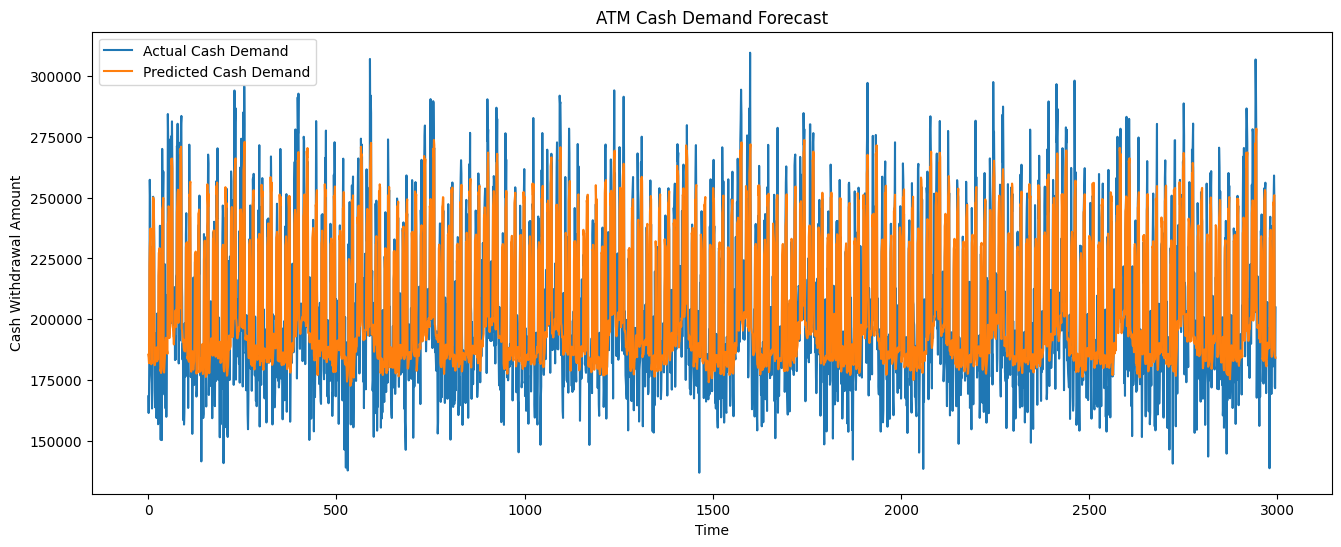

In [27]:
# =====================================================
# Actual vs Predicted
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(actual,label='Actual Cash Demand')
plt.plot(predictions,label='Predicted Cash Demand')

plt.title("ATM Cash Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Cash Withdrawal Amount")
plt.legend()

plt.show()

In [ ]:
# =====================================================
# Evaluation
# =====================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(actual,predictions)

rmse = np.sqrt(
    mean_squared_error(actual,predictions)
)

r2 = r2_score(actual,predictions)

print("Model Evaluation")
print("------------------------")
print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

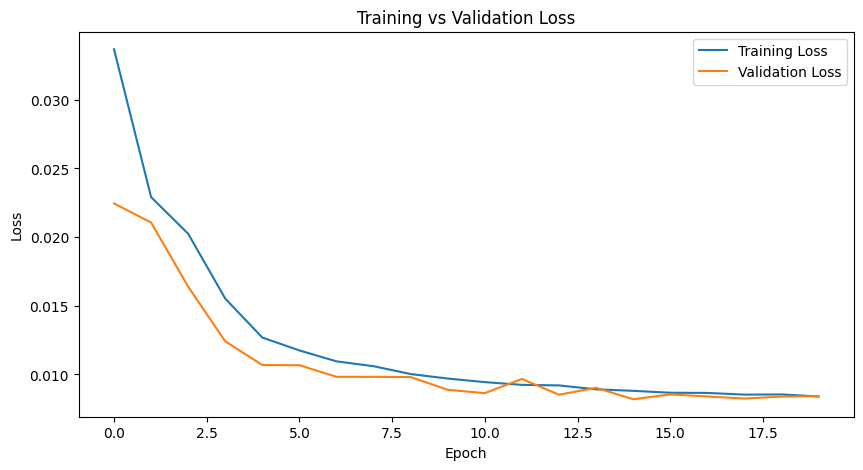

In [28]:
# =====================================================
# Training Loss
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [29]:
# =====================================================
# Forecast Next 24 Hours
# =====================================================

last_sequence = scaled_data[-24:]
current_sequence = last_sequence.reshape(1,24,1)

future_predictions = []

for i in range(24):

    pred = model.predict(current_sequence, verbose=0)

    future_predictions.append(pred[0,0])

    current_sequence = np.append(
        current_sequence[:,1:,:],
        [[[pred[0,0]]]],
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("Next 24 Hours Cash Demand Forecast")

for i,value in enumerate(future_predictions):
    print(f"Hour {i+1}: ₹{value[0]:,.2f}")

Next 24 Hours Cash Demand Forecast
Hour 1: ₹183,883.61
Hour 2: ₹185,215.69
Hour 3: ₹187,098.47
Hour 4: ₹190,215.98
Hour 5: ₹185,797.05
Hour 6: ₹185,443.78
Hour 7: ₹185,895.22
Hour 8: ₹185,105.73
Hour 9: ₹236,171.91
Hour 10: ₹235,957.14
Hour 11: ₹237,277.44
Hour 12: ₹233,698.28
Hour 13: ₹184,495.20
Hour 14: ₹183,446.03
Hour 15: ₹186,372.80
Hour 16: ₹187,411.75
Hour 17: ₹185,923.36
Hour 18: ₹254,127.28
Hour 19: ₹251,509.84
Hour 20: ₹254,817.61
Hour 21: ₹255,730.72
Hour 22: ₹184,569.56
Hour 23: ₹183,816.95
Hour 24: ₹183,865.95


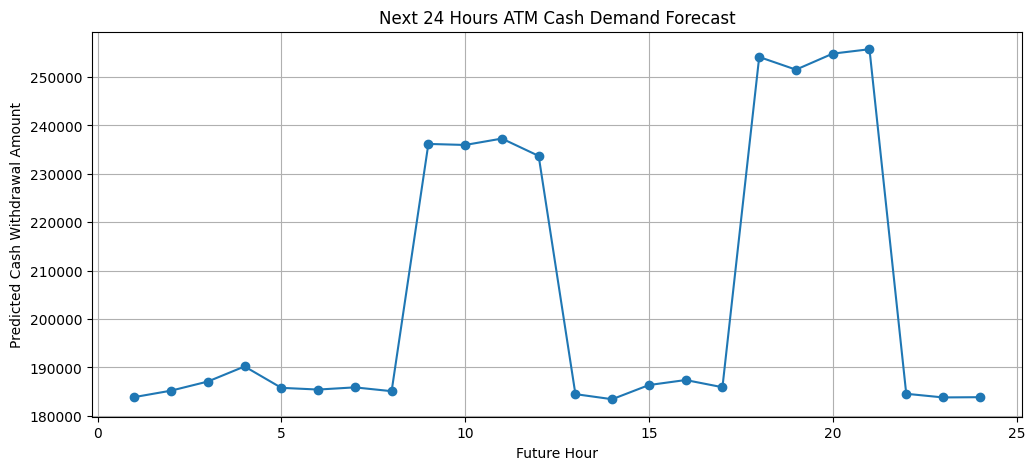

In [30]:
# =====================================================
# Future Forecast Graph
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(
    range(1,25),
    future_predictions,
    marker='o'
)

plt.title("Next 24 Hours ATM Cash Demand Forecast")
plt.xlabel("Future Hour")
plt.ylabel("Predicted Cash Withdrawal Amount")

plt.grid(True)

plt.show()

In [31]:
# =====================================================
# Save LSTM Model
# =====================================================

model.save("atm_cash_lstm_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [32]:
# =====================================================
# Save Scaler
# =====================================================

import joblib

joblib.dump(scaler, "cash_scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [33]:
# =====================================================
# Load Model
# =====================================================

from tensorflow.keras.models import load_model

loaded_model = load_model("atm_cash_lstm_model.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [34]:
# =====================================================
# Load Model
# =====================================================

from tensorflow.keras.models import load_model

loaded_model = load_model("atm_cash_lstm_model.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [35]:
# =====================================================
# Load Scaler
# =====================================================

loaded_scaler = joblib.load("cash_scaler.pkl")

print("Scaler loaded successfully.")

Scaler loaded successfully.


In [36]:
# =====================================================
# Prediction Using Saved Model
# =====================================================

last_sequence = scaled_data[-24:]
last_sequence = last_sequence.reshape(1,24,1)

prediction = loaded_model.predict(last_sequence)

prediction = loaded_scaler.inverse_transform(prediction)

print("Predicted Next Hour Cash Demand : ₹", round(prediction[0][0],2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
Predicted Next Hour Cash Demand : ₹ 183883.6


In [37]:
# =====================================================
# Download Files
# =====================================================

from google.colab import files

files.download("atm_cash_lstm_model.keras")
files.download("cash_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
from tensorflow.keras.models import load_model

model = load_model("atm_cash_lstm_model.keras")

print("Input Shape :", model.input_shape)
print("Output Shape:", model.output_shape)

model.summary()

Input Shape : (None, 24, 1)
Output Shape: (None, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,715 (604.36 KB)

 Trainable params: 51,571 (201.45 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,715 (604.36 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 103,144 (402.91 KB)